# Project on Diwali Sales Analysis

In [2]:
# Import Python Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt # Visualizing Data
%matplotlib inline
import seaborn as sns

In [3]:
df = pd.read_csv("Diwali Sales Data.csv", encoding = "unicode_escape")

In [4]:
df.shape

(11251, 15)

In [5]:
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [7]:
# Drop Blank Columns

df.drop(['Status','unnamed1'], axis = 1, inplace = True)

In [8]:
# Check for Null values

pd.isnull(df).sum()

,0
User_ID,0
Cust_name,0
Product_ID,0
Gender,0
Age Group,0
Age,0
Marital_Status,0
State,0
Zone,0
Occupation,0


In [9]:
# Drop Null Values

df.dropna(inplace = True)

In [10]:
# Change Datatype

df['Amount'] = df['Amount'].astype('int')

In [11]:
df['Amount'].dtypes

dtype('int64')

In [12]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

In [13]:
df.rename(columns = {'Marital_Status':'Marriage'})

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marriage,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11246,1000695,Manning,P00296942,M,18-25,19,1,Maharashtra,Western,Chemical,Office,4,370
11247,1004089,Reichenbach,P00171342,M,26-35,33,0,Haryana,Northern,Healthcare,Veterinary,3,367
11248,1001209,Oshin,P00201342,F,36-45,40,0,Madhya Pradesh,Central,Textile,Office,4,213
11249,1004023,Noonan,P00059442,M,36-45,37,0,Karnataka,Southern,Agriculture,Office,3,206


In [14]:
# Description of Data

df.describe()

,User_ID,Age,Marital_Status,Orders,Amount
count,1.123900e+04,11239.000000,11239.000000,11239.000000,11239.000000
mean,1.003004e+06,35.410357,0.420055,2.489634,9453.610553
std,1.716039e+03,12.753866,0.493589,1.114967,5222.355168
min,1.000001e+06,12.000000,0.000000,1.000000,188.000000
25%,1.001492e+06,27.000000,0.000000,2.000000,5443.000000
50%,1.003064e+06,33.000000,0.000000,2.000000,8109.000000
75%,1.004426e+06,43.000000,1.000000,3.000000,12675.000000
max,1.006040e+06,92.000000,1.000000,4.000000,23952.000000


In [15]:
# Get Description of Specific columns

df[['Amount','Orders','Amount']].describe()

,Amount,Orders,Amount
count,11239.000000,11239.000000,11239.000000
mean,9453.610553,2.489634,9453.610553
std,5222.355168,1.114967,5222.355168
min,188.000000,1.000000,188.000000
25%,5443.000000,2.000000,5443.000000
50%,8109.000000,2.000000,8109.000000
75%,12675.000000,3.000000,12675.000000
max,23952.000000,4.000000,23952.000000


## **EDA (Exploratory Data Analysis)**

### **Gender**

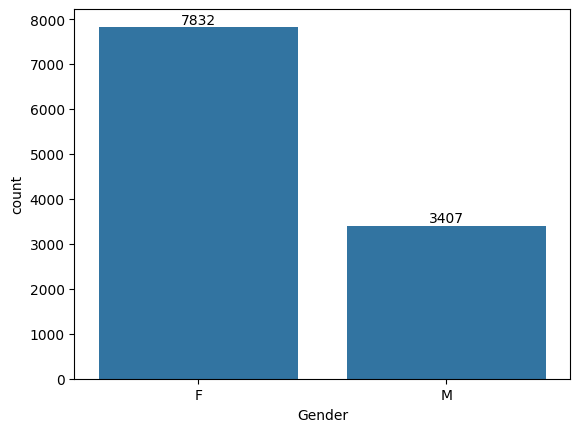

In [16]:
# Plotting a bar chart for Gender and it's count

ax = sns.countplot(x = 'Gender', data = df)

for bars in ax.containers:
  ax.bar_label(bars)

<Axes: xlabel='Gender', ylabel='Amount'>

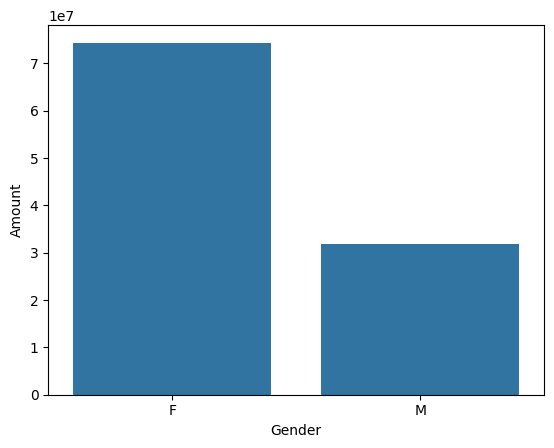

In [17]:
# Plotting a bar chart for Gender vs Total Amount

sales_gen = df.groupby(['Gender'], as_index = False)['Amount'].sum().sort_values(by = 'Amount', ascending = False)
sns.barplot(x = 'Gender', y = 'Amount', data = sales_gen)

*Note - From above graphs we can see that most of the buyes are Females and even the purchasing power of Females are greater than Males.*

### Age

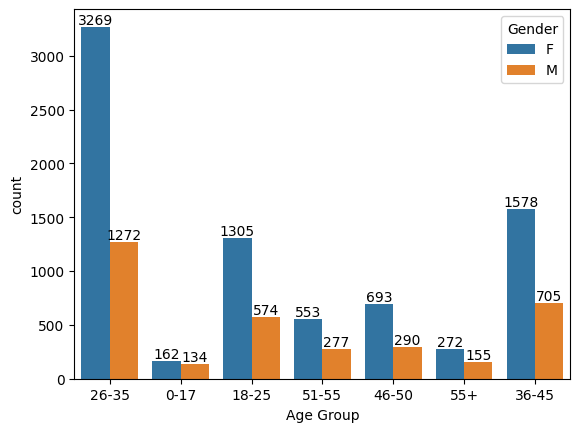

In [18]:
# Plotting a bar chart for Total count of Age Groups

ax = sns.countplot(data = df, x = 'Age Group', hue = 'Gender')
for bars in ax.containers:
  ax.bar_label(bars)

<Axes: xlabel='Age Group', ylabel='Amount'>

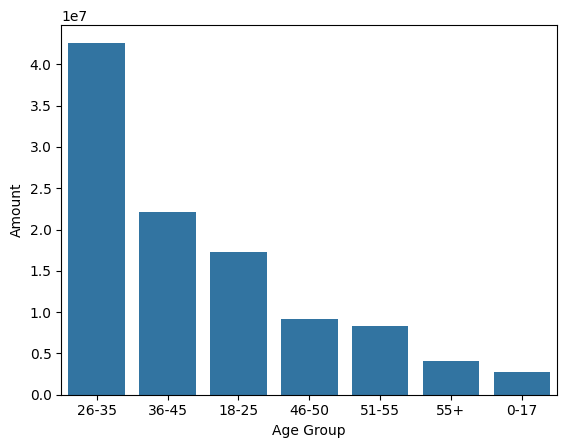

In [20]:
# Total Amount vs Age Groups

sales_age = df.groupby(['Age Group'], as_index = False)['Amount'].sum().sort_values(by = 'Amount', ascending = False)
sns.barplot(x = 'Age Group', y = 'Amount', data = sales_age)

*Note - From above graphs we can see that most of the buyers are of age group between 26-35 years Female*

### State

<Axes: xlabel='State', ylabel='Orders'>

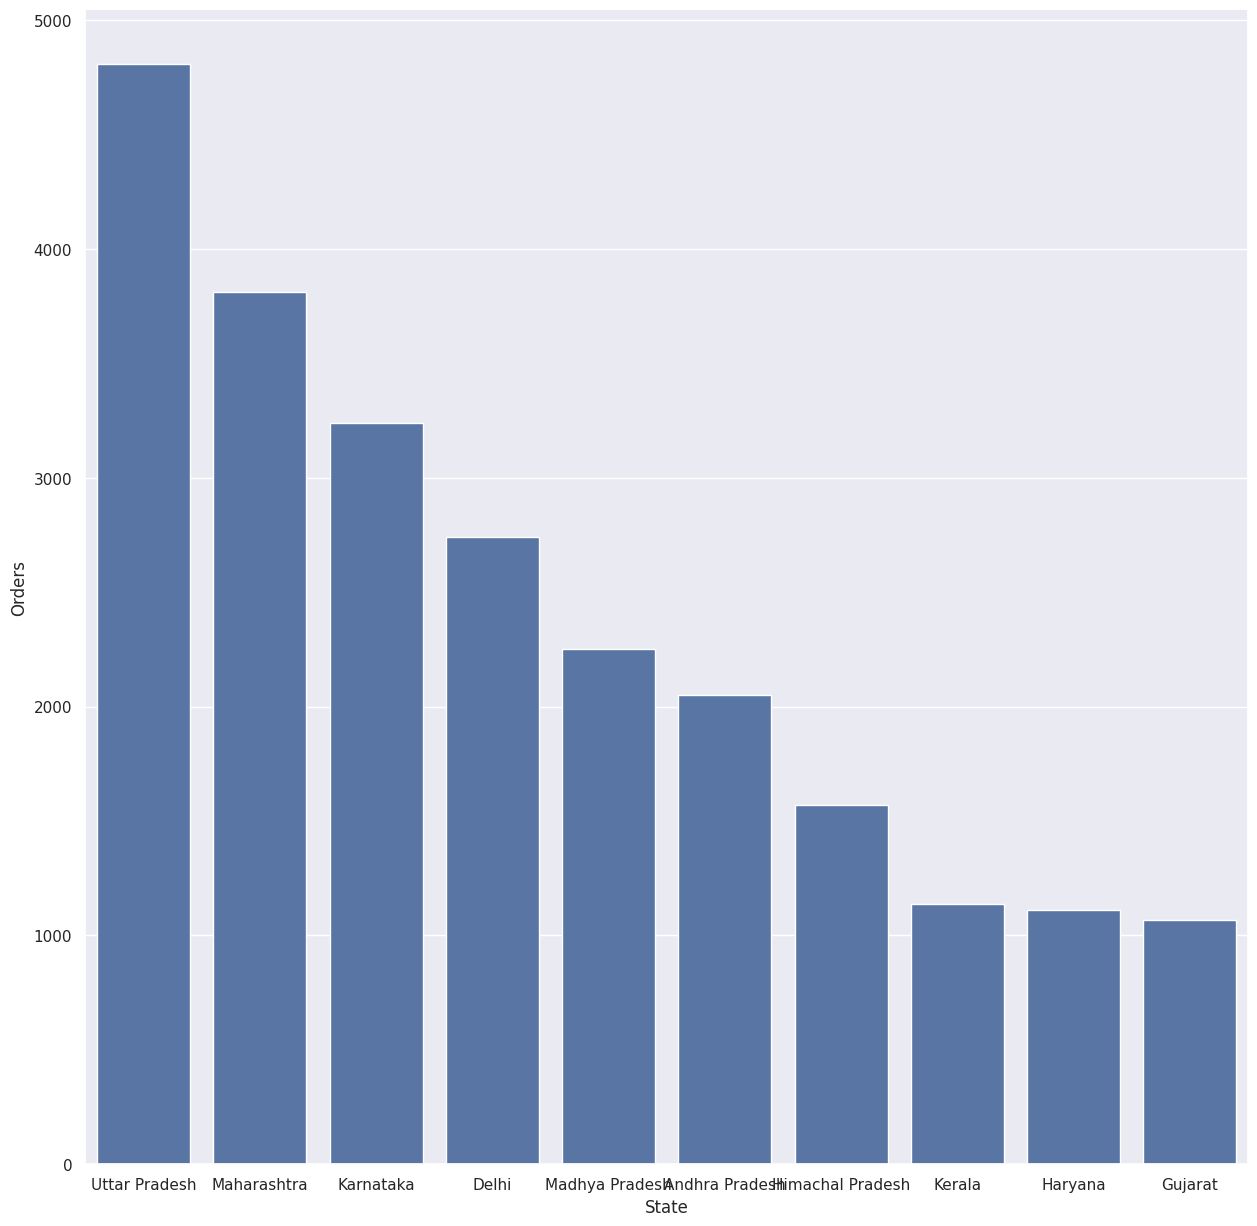

In [22]:
# Total number of orders from top 10 States

sales_state = df.groupby(['State'], as_index = False)['Orders'].sum().sort_values(by = 'Orders', ascending = False).head(10)
sns.set(rc = {'figure.figsize':(15,15)})
sns.barplot(data = sales_state, x = 'State', y = 'Orders')

<Axes: xlabel='State', ylabel='Amount'>

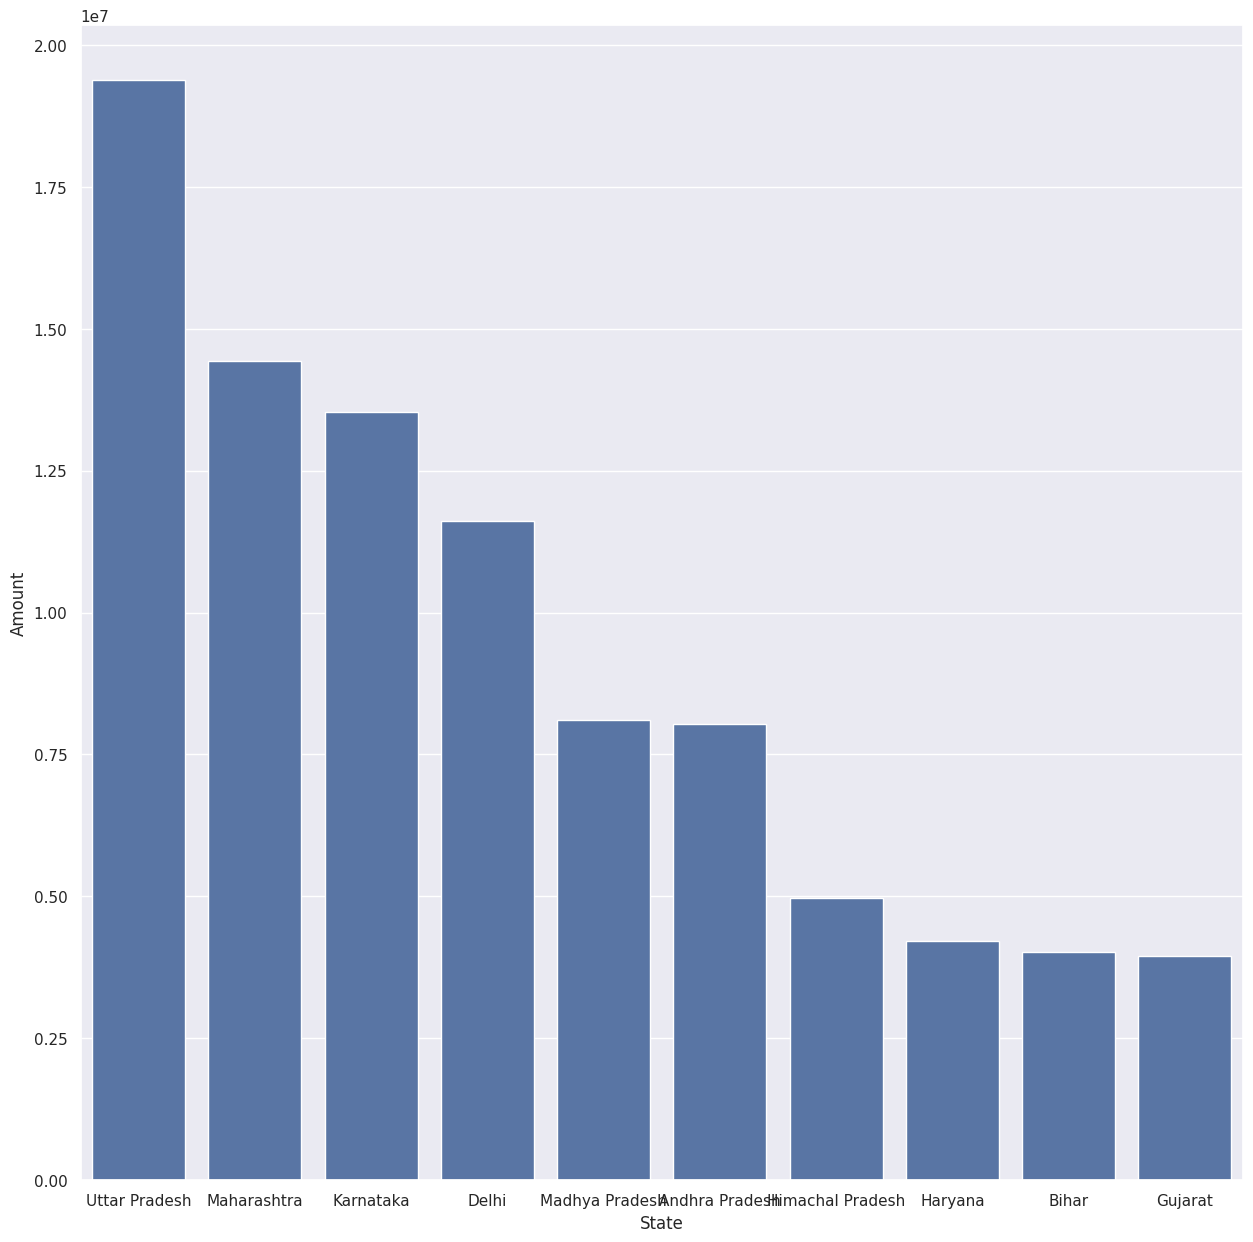

In [23]:
# Total amount/Sales from top 10 States

sales_state = df.groupby(['State'], as_index = False)['Amount'].sum().sort_values(by = 'Amount',ascending = False).head(10)
sns.set(rc = {'figure.figsize':(15,15)})
sns.barplot(data = sales_state, x = 'State', y = 'Amount')

*Note - From above graphs we can see that most of the Orders and Total Sales/Amount are form Uttar Pradesh, Maharashtra and Karnataka respectively*

### Marital Status

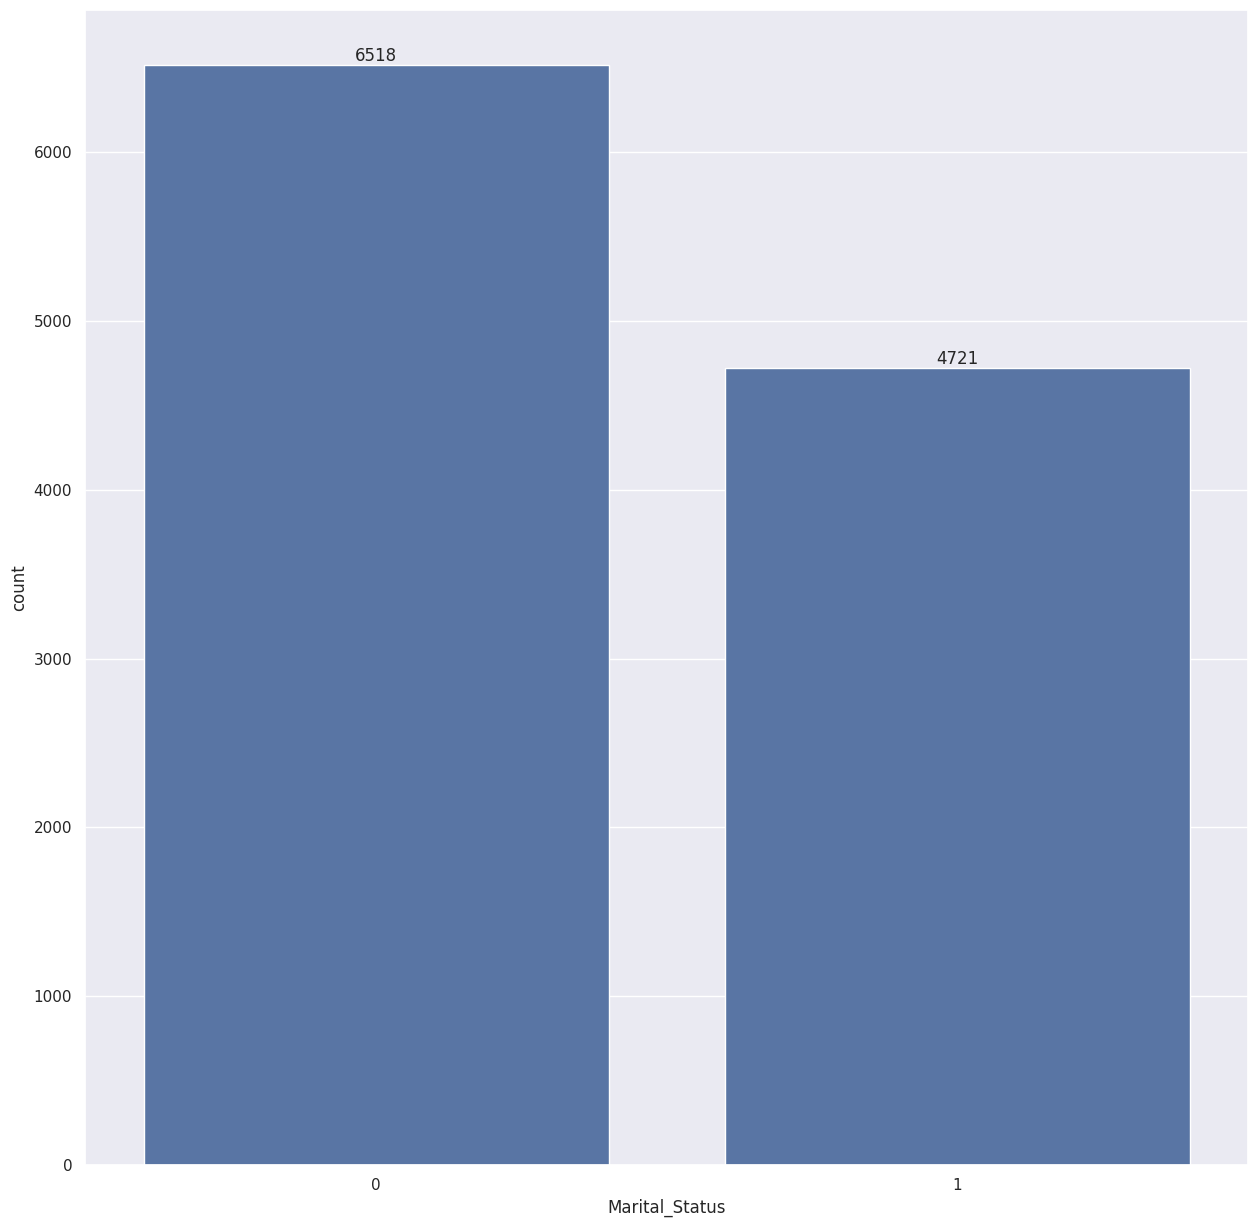

In [24]:
# Plotting the bar chart of Marital Status

ax = sns.countplot(data = df, x = 'Marital_Status')
sns.set(rc = {'figure.figsize':(7,5)})
for bars in ax.containers:
  ax.bar_label(bars)

<Axes: xlabel='Marital_Status', ylabel='Amount'>

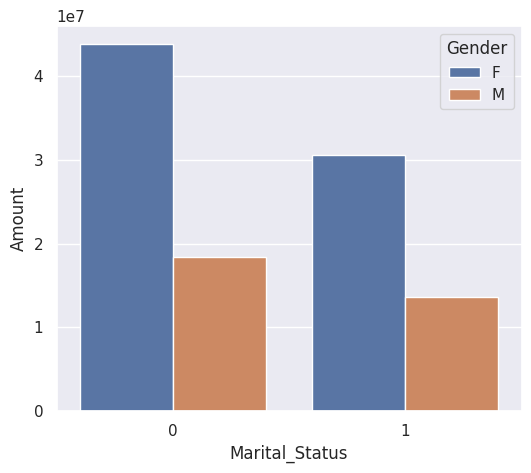

In [26]:
# Plotting bar chart of Marital Status vs Total Amount

sales_state = df.groupby(['Marital_Status', 'Gender'], as_index = False)['Amount'].sum().sort_values(by = 'Amount', ascending = False)
sns.set(rc = {'figure.figsize':(6,5)})
sns.barplot(data = sales_state, x = 'Marital_Status', y = 'Amount', hue = 'Gender')

*Note - From above graphs we can see that most of the buyers are Married(Women) and they have high purchasing power*

### Occupation

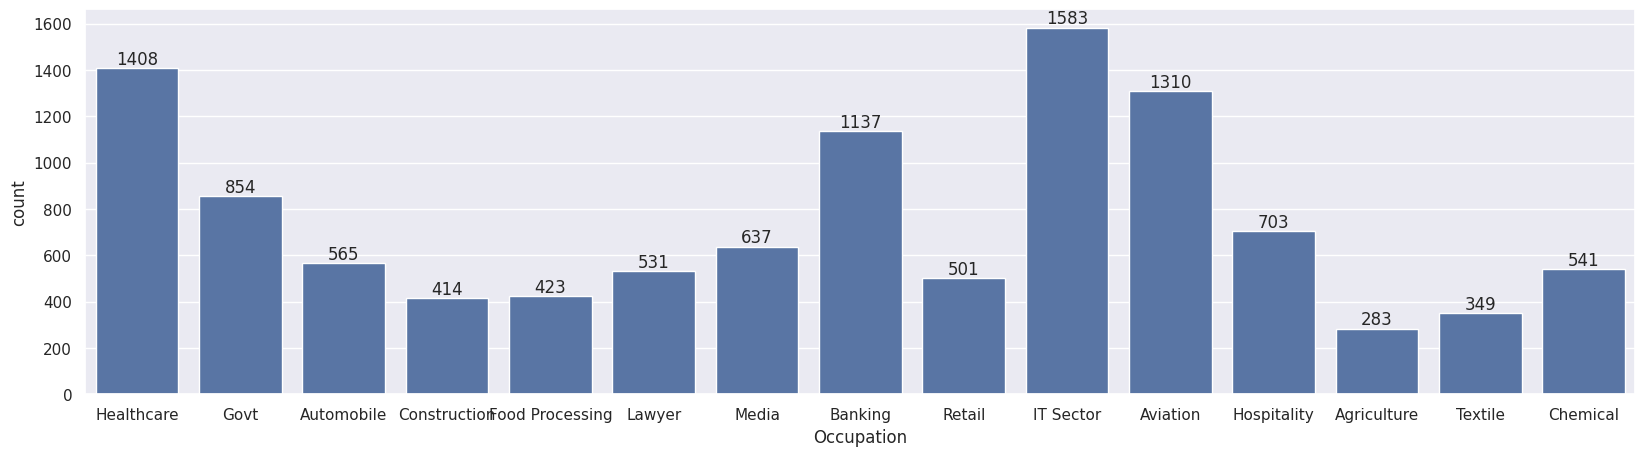

In [27]:
# Plotting the bar chart on the basis of their Occupations

sns.set(rc = {'figure.figsize':(20,5)})
ax = sns.countplot(data = df, x = 'Occupation')
for bars in ax.containers:
  ax.bar_label(bars)

<Axes: xlabel='Occupation', ylabel='Amount'>

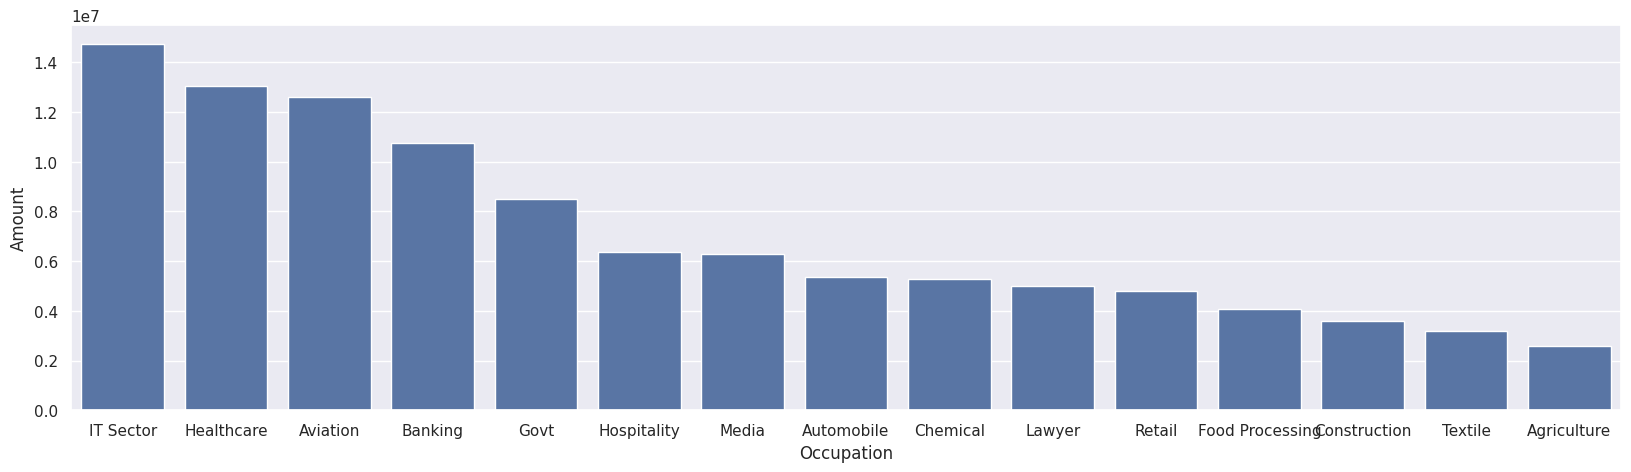

In [28]:
# Plotting the bar chart of Occupation vs Total Amount

sales_state = df.groupby(['Occupation'], as_index = False)['Amount'].sum().sort_values(by = 'Amount', ascending = False)
sns.set(rc = {'figure.figsize': (20,5)})
sns.barplot(data = sales_state, x = 'Occupation', y = 'Amount')

*Note - From above graphs we can see that most of the buyers are working in IT, Healthcare and Aviation Sector.*

### Product Category

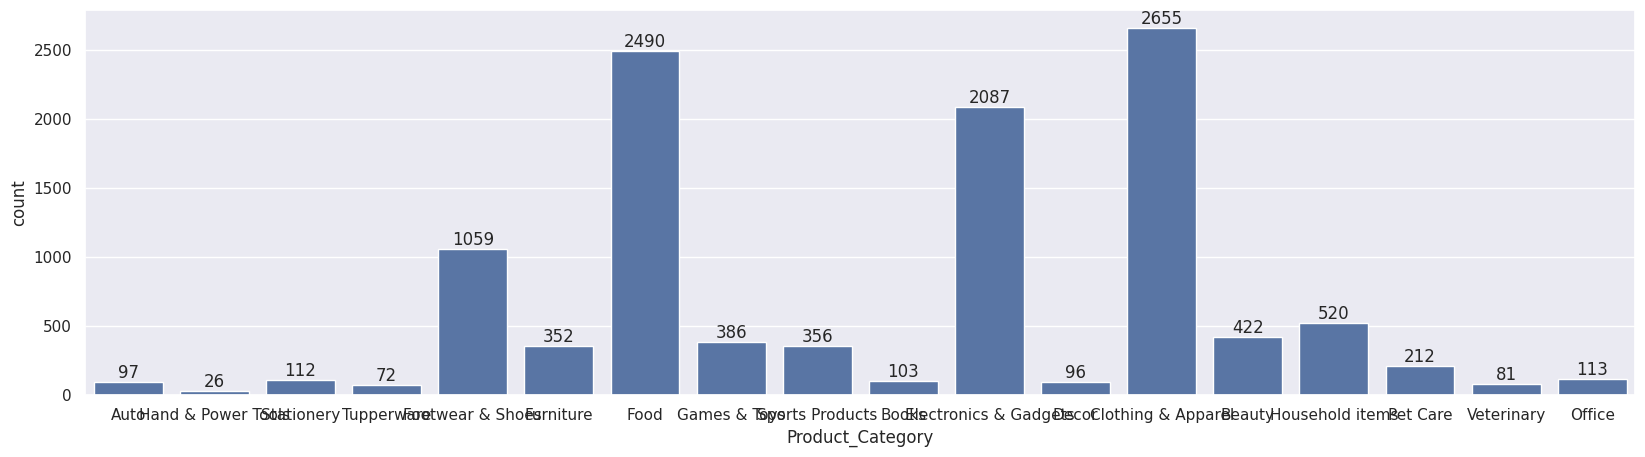

In [29]:
# Plotting the bar charts on Product Category

sns.set(rc = {'figure.figsize': (20,5)})
ax = sns.countplot(data = df, x = 'Product_Category')
for bars in ax.containers:
  ax.bar_label(bars)

<Axes: xlabel='Product_Category', ylabel='Amount'>

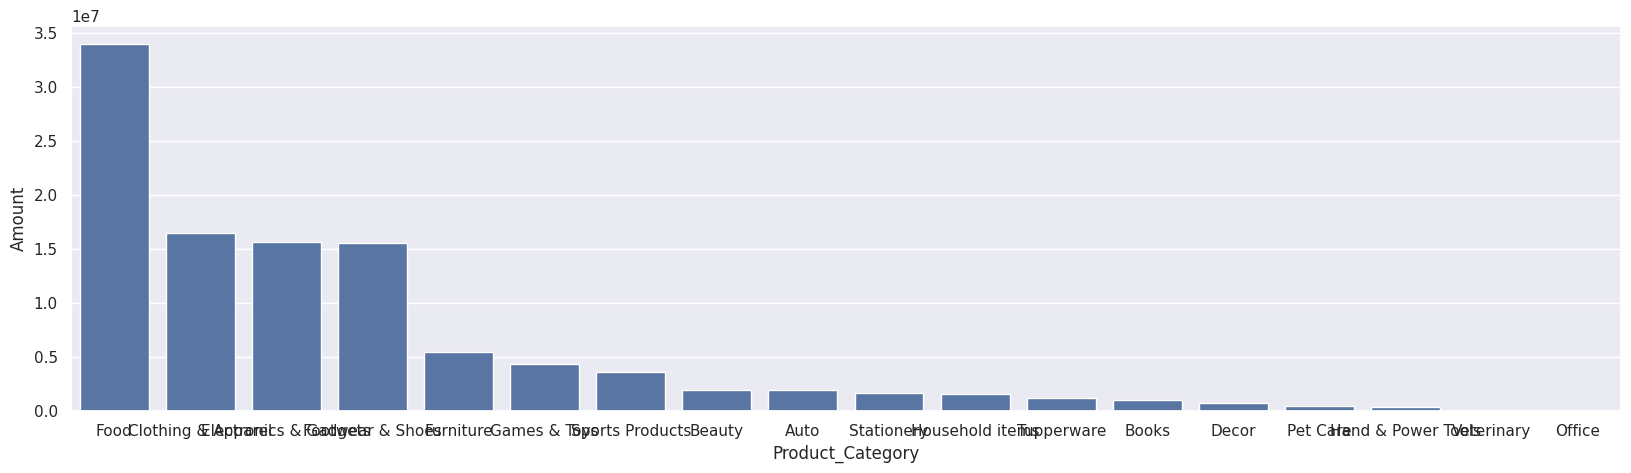

In [31]:
# Plotting the bar chart on Product Category vs Total Amount

sales_state = df.groupby(['Product_Category'], as_index = False)['Amount'].sum().sort_values(by = 'Amount', ascending = False)
sns.set(rc = {'figure.figsize':(20,5)})
sns.barplot(data = sales_state, x = 'Product_Category', y = 'Amount')

*Note - From above graphsphs we can see that most of the sold Products are from Food, Clothing and Electronics Category.*

<Axes: xlabel='Product_ID', ylabel='Orders'>

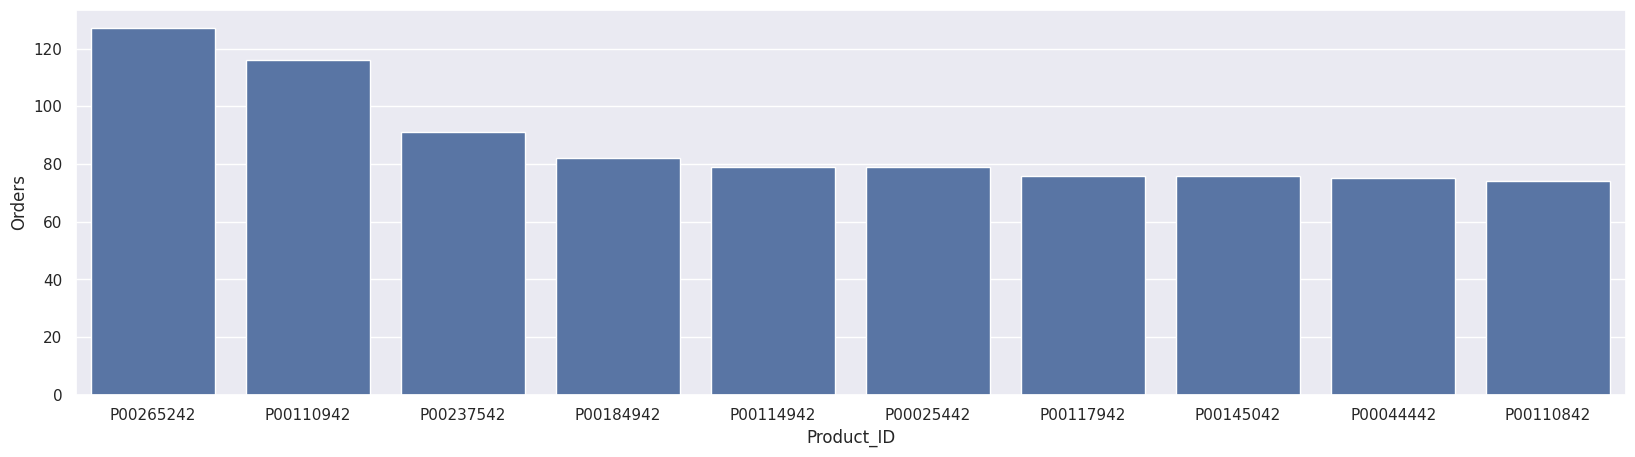

In [33]:
# Plotting the bar chart on Product ID vs Orders

sales_state = df.groupby(['Product_ID'], as_index = False)['Orders'].sum().sort_values(by = ['Orders'], ascending = False).head(10)
sns.set(rc = {'figure.figsize':(20,5)})
sns.barplot(data = sales_state, x = 'Product_ID', y = 'Orders')

<Axes: xlabel='Product_ID'>

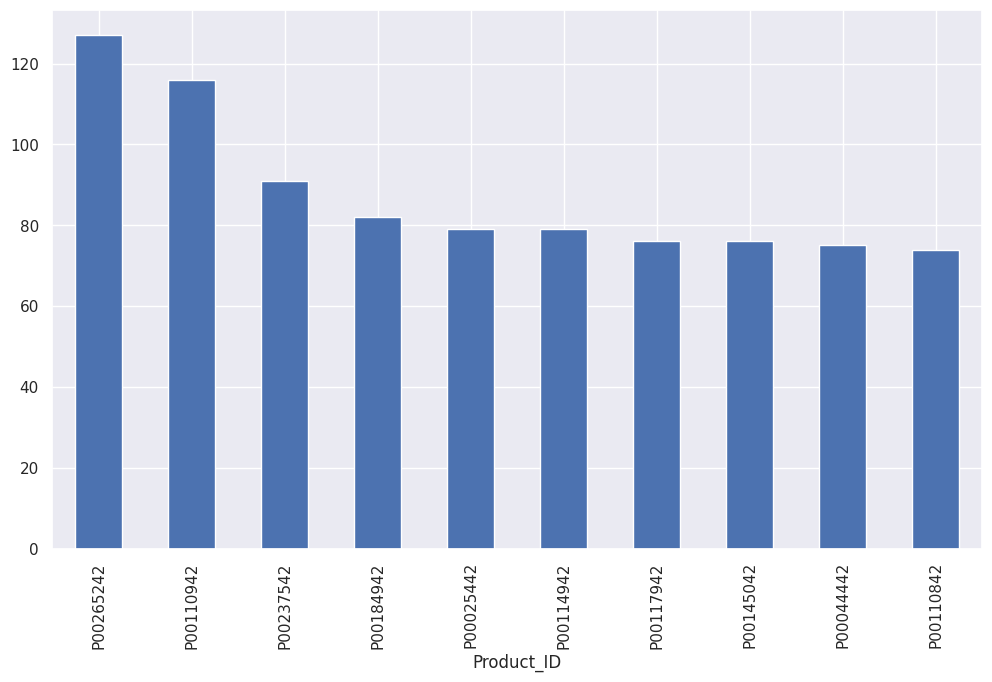

In [35]:
# Top 10 most sold Products

fif1, ax1 = plt.subplots(figsize = (12,7))
df.groupby('Product_ID')['Orders'].sum().nlargest(10).sort_values(ascending = False).plot(kind = 'bar')

## Conclusion :

Married women age group of 26-35 years from UP, Maharshtra and Karnataka working in IT, Healthcare and Aviation are more likely to buy Products from Food, Clothing and Electronics category.